In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import ks_2samp

#### Functions

In [2]:
# compute evaluation metrics
def compute_metrics(arr_y_true, arr_y_pred):
    flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
    flt_gini = 2 * flt_auc - 1
    flt_ks = ks_2samp(arr_y_pred[arr_y_true == 1], arr_y_pred[arr_y_true == 0]).statistic
    return {'flt_auc': flt_auc, 'flt_gini': flt_gini, 'flt_ks': flt_ks}

In [3]:
# plot roc curves
def plot_roc_curves(dict_splits, str_filename='output/roc_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        flt_auc = roc_auc_score(arr_y_true, arr_y_pred)
        arr_fpr, arr_tpr, _ = roc_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_fpr, arr_tpr, color=str_color, linewidth=2, label=f'{str_name} (AUC={flt_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('ROC Curves', fontsize=16)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [4]:
# plot precision recall curves
def plot_precision_recall_curves(dict_splits, str_filename='output/precision_recall_curves.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        arr_precision, arr_recall, _ = precision_recall_curve(arr_y_true, arr_y_pred)
        ax.plot(arr_recall, arr_precision, color=str_color, linewidth=2, label=str_name)
    ax.set_title('Precision-Recall Curves', fontsize=16)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [5]:
# plot calibration
def plot_calibration(dict_splits, int_n_bins=10, str_filename='output/calibration.png'):
    fig, ax = plt.subplots(figsize=(8, 6))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        arr_bins = np.linspace(0, 1, int_n_bins + 1)
        arr_bin_indices = np.digitize(arr_y_pred, arr_bins) - 1
        arr_bin_indices = np.clip(arr_bin_indices, 0, int_n_bins - 1)
        list_predicted = []
        list_actual = []
        for i in range(int_n_bins):
            arr_mask = arr_bin_indices == i
            if arr_mask.sum() > 0:
                list_predicted.append(arr_y_pred[arr_mask].mean())
                list_actual.append(arr_y_true[arr_mask].mean())
        ax.plot(list_predicted, list_actual, marker='o', color=str_color, linewidth=2, label=str_name)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title('Calibration Plot', fontsize=16)
    ax.set_xlabel('Mean Predicted Probability', fontsize=12)
    ax.set_ylabel('Actual Default Rate', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [6]:
# plot kde of predictions
def plot_kde_predictions(dict_splits, str_filename='output/kde_predictions.png'):
    warnings.filterwarnings('ignore')
    fig, ax = plt.subplots(figsize=(10, 5))
    list_colors = ['steelblue', 'salmon', 'seagreen']
    for (str_name, (arr_y_true, arr_y_pred)), str_color in zip(dict_splits.items(), list_colors):
        sns.kdeplot(arr_y_pred, ax=ax, color=str_color, linewidth=2, label=str_name, fill=True, alpha=0.2)
    ax.set_title('KDE of Predictions', fontsize=16)
    ax.set_xlabel('Predicted Probability', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()
    warnings.filterwarnings('default')

In [7]:
# plot confusion matrix
def plot_confusion_matrix(arr_y_true, arr_y_pred, flt_threshold=0.5, str_filename='output/confusion_matrix.png'):
    arr_y_class = (arr_y_pred >= flt_threshold).astype(int)
    arr_cm = confusion_matrix(arr_y_true, arr_y_class)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(arr_cm, display_labels=['No Default', 'Default']).plot(ax=ax, cmap='Blues')
    ax.set_title(f'Confusion Matrix (Threshold={flt_threshold})', fontsize=16)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [8]:
# plot shap partial dependence plots
def plot_shap_pdp(model, arr_X, list_feature_cols, str_filename='output/shap_pdp.png'):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(arr_X)
    int_n_features = len(list_feature_cols)
    int_n_cols = 3
    int_n_rows = int(np.ceil(int_n_features / int_n_cols))
    fig, axes = plt.subplots(int_n_rows, int_n_cols, figsize=(6 * int_n_cols, 4 * int_n_rows))
    axes = axes.flatten()
    for i, str_col in enumerate(list_feature_cols):
        ax = axes[i]
        ax.scatter(arr_X[:, i], shap_values[:, i], alpha=0.3, s=5, color='steelblue')
        ax.set_title(str_col, fontsize=12)
        ax.set_xlabel('Feature Value', fontsize=10)
        ax.set_ylabel('SHAP Value', fontsize=10)
        ax.axhline(y=0, color='black', linewidth=0.5)
    # hide unused axes
    for j in range(int_n_features, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('SHAP Partial Dependence Plots', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300, bbox_inches='tight')
    plt.show()

#### Constants

In [9]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/03_preprocessing'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# model and feature columns
str_model_path = '../04_model/output/xgboost_model.joblib'
str_feature_cols_path = '../04_model/output/feature_cols.joblib'

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 05_model_eval
S3 Input: s3://credit-risk-claude/03_preprocessing
Target: default_12m


#### Read Data and Model

In [10]:
# read preprocessed data
df_train = pd.read_parquet(f'{str_s3_input}/df_train_clean.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid_clean.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test_clean.parquet')

# load model and feature columns
model = joblib.load(str_model_path)
list_feature_cols = joblib.load(str_feature_cols_path)

print(f'Train: {df_train.shape}')
print(f'Validation: {df_valid.shape}')
print(f'Test: {df_test.shape}')
print(f'Features: {len(list_feature_cols)}')

Train: (17715, 20)
Validation: (3796, 20)
Test: (3797, 20)
Features: 12


/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


#### Generate Predictions

In [11]:
# generate predictions
arr_y_train = df_train[str_target].values
arr_y_valid = df_valid[str_target].values
arr_y_test = df_test[str_target].values

arr_pred_train = model.predict_proba(df_train[list_feature_cols].values)[:, 1]
arr_pred_valid = model.predict_proba(df_valid[list_feature_cols].values)[:, 1]
arr_pred_test = model.predict_proba(df_test[list_feature_cols].values)[:, 1]

# dict for passing to plot functions
dict_splits = {
    'Train': (arr_y_train, arr_pred_train),
    'Validation': (arr_y_valid, arr_pred_valid),
    'Test': (arr_y_test, arr_pred_test),
}

#### Metrics Summary

AUC, Gini (2*AUC-1), and KS statistic across all splits. Gini is the standard discrimination metric in credit risk. KS measures the maximum separation between the cumulative distributions of defaulters and non-defaulters.

In [12]:
# compute metrics for each split
list_rows = []
for str_name, (arr_y_true, arr_y_pred) in dict_splits.items():
    dict_metrics = compute_metrics(arr_y_true, arr_y_pred)
    dict_metrics['str_split'] = str_name
    list_rows.append(dict_metrics)

df_metrics = pd.DataFrame(list_rows)[['str_split', 'flt_auc', 'flt_gini', 'flt_ks']]
df_metrics.to_csv('output/metrics_summary.csv', index=False)
df_metrics

,str_split,flt_auc,flt_gini,flt_ks
0,Train,0.815849,0.631697,0.473789
1,Validation,0.784276,0.568551,0.429714
2,Test,0.801606,0.603212,0.464789


#### ROC Curves

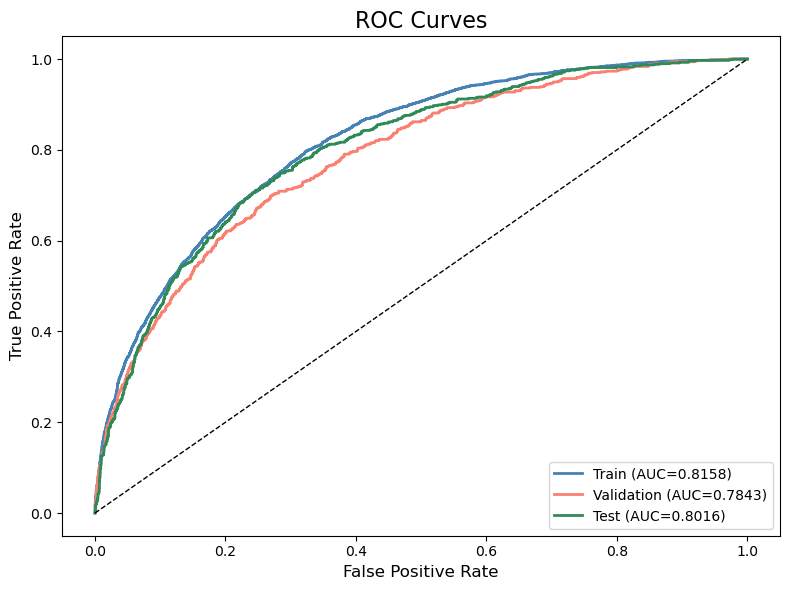

In [13]:
plot_roc_curves(dict_splits)

#### Precision-Recall Curves

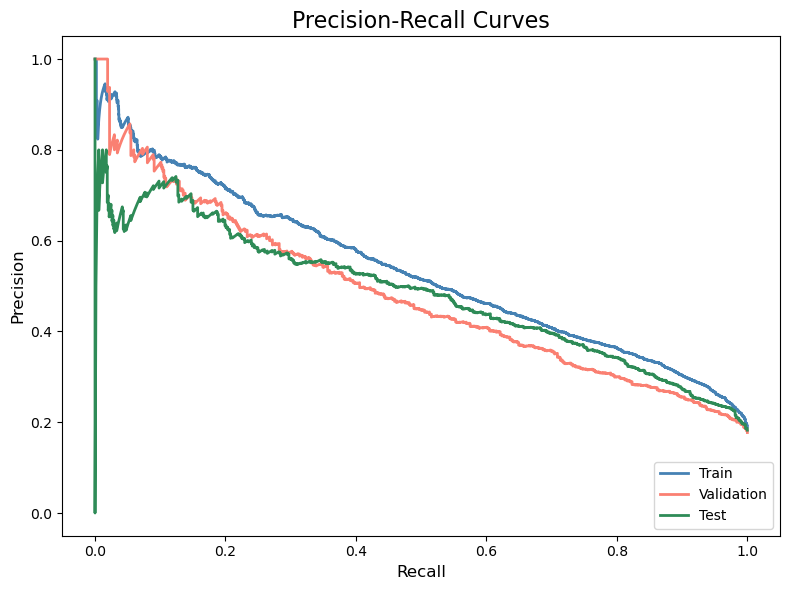

In [14]:
plot_precision_recall_curves(dict_splits)

#### Calibration

Calibration measures how well the predicted probabilities match actual default rates. A well-calibrated model's points will fall close to the diagonal. This is critical for credit risk because predicted probabilities are used directly for pricing and capital allocation.

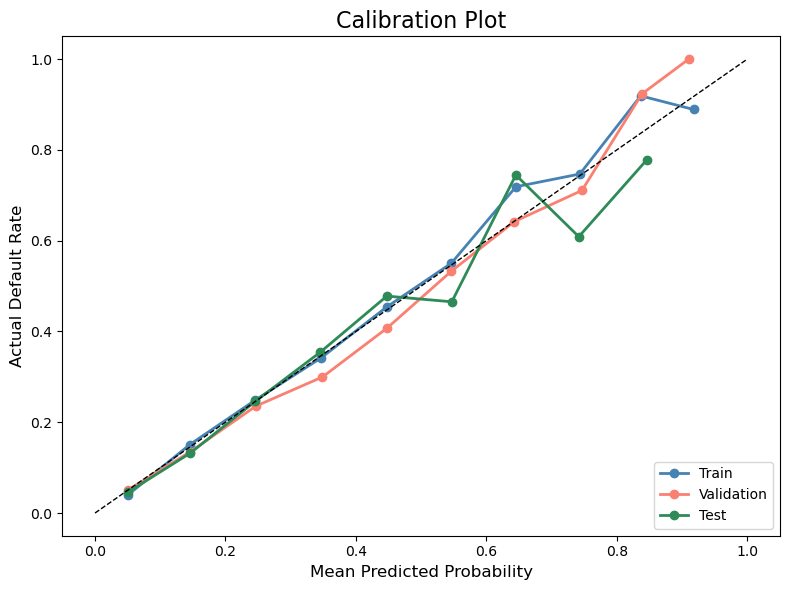

In [15]:
plot_calibration(dict_splits)

#### KDE of Predictions

KDE plots show the distribution of predicted probabilities across splits. Similar distributions indicate stable model behavior across train, validation, and test. Divergence may indicate overfitting or data drift.

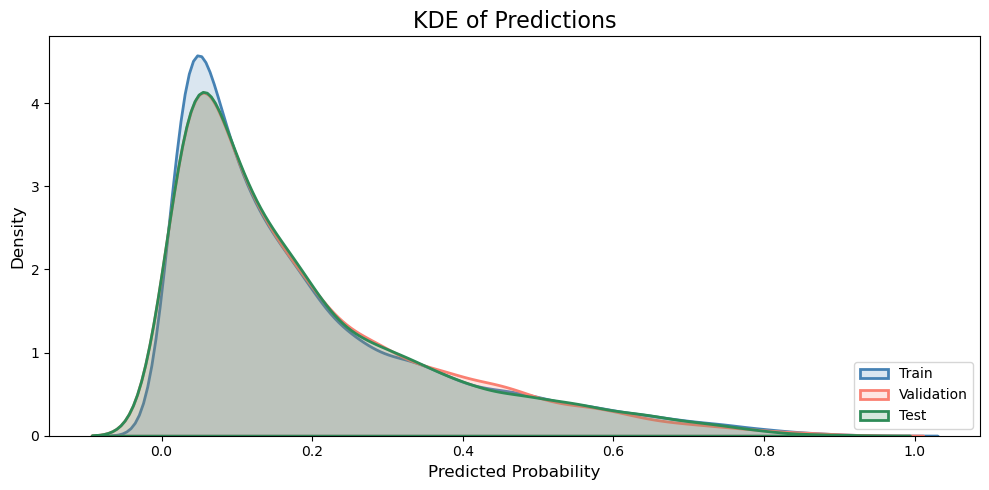

In [16]:
plot_kde_predictions(dict_splits)

#### Confusion Matrix (Test Set)

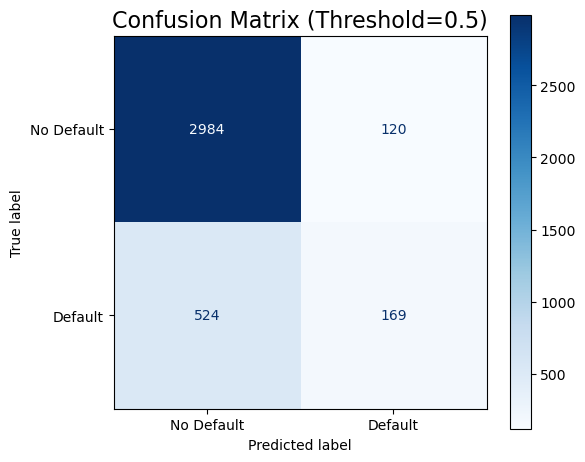

In [17]:
plot_confusion_matrix(arr_y_test, arr_pred_test)

#### SHAP Partial Dependence Plots

SHAP partial dependence plots show the relationship between each feature's value and its SHAP contribution to the prediction. These are useful for verifying that monotone constraints are being respected and for understanding the nonlinear relationships the model has learned.

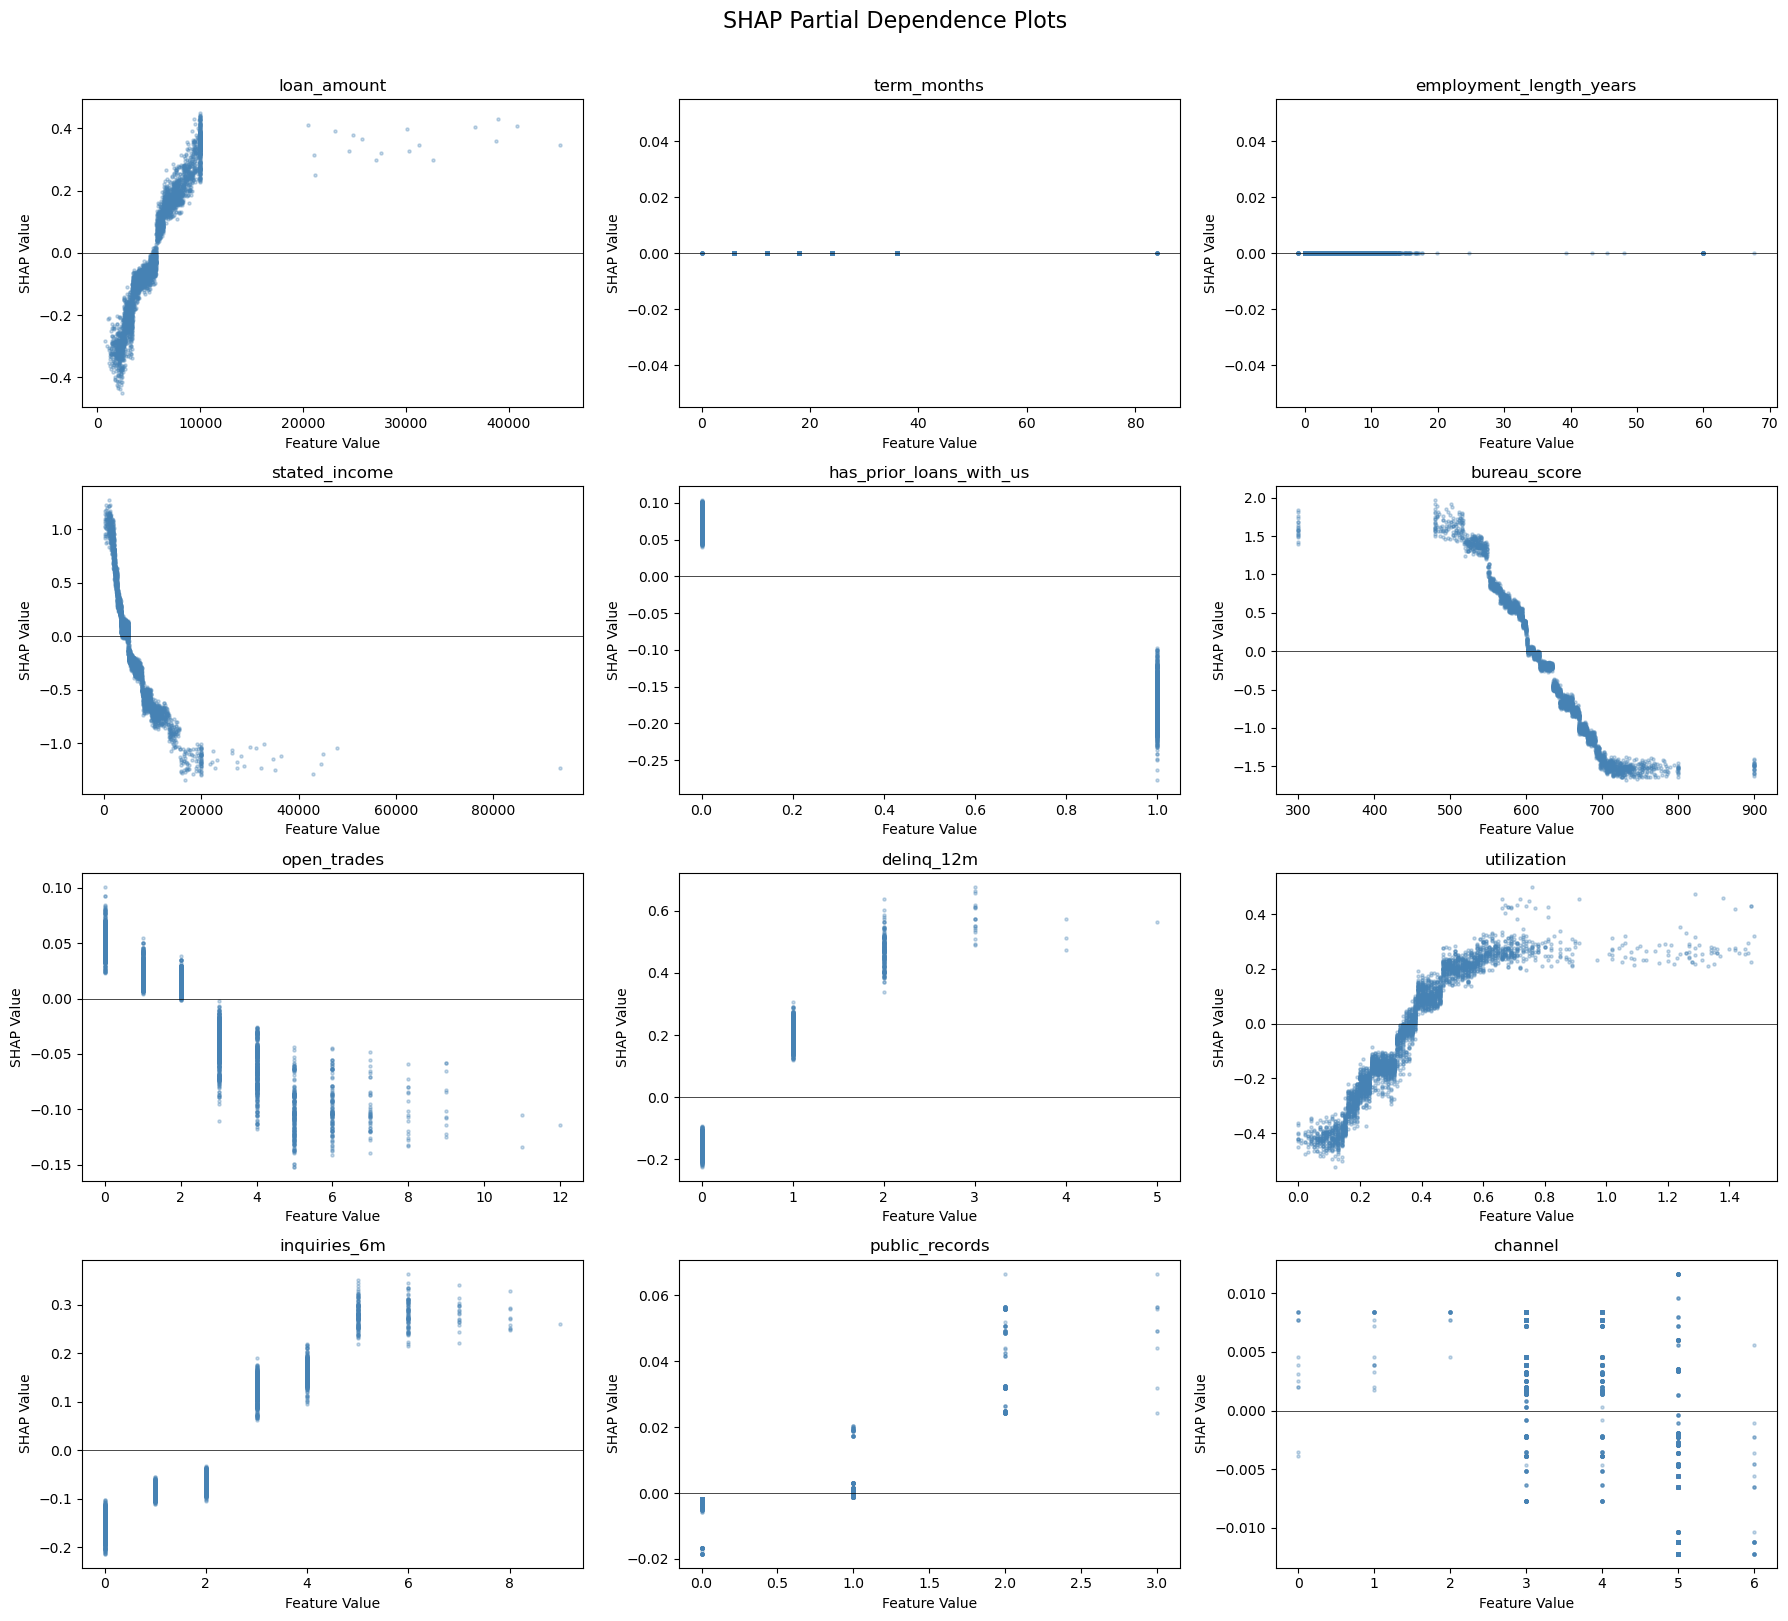

In [18]:
plot_shap_pdp(model, df_test[list_feature_cols].values, list_feature_cols)